# Evaluación del modelo por segmento: ¿el desempeño es parejo?

**Autor:** John Janer Buila Ferrin

Las métricas agregadas (PR-AUC, F1, ROC-AUC) reportadas para el modelo campeón
resumen el desempeño sobre todo el conjunto de prueba, pero pueden ocultar
diferencias importantes entre subgrupos de sesiones. Este notebook retoma los
segmentos ya caracterizados en el análisis exploratorio de la Entrega 1
(`VisitorType`, `TrafficType`, `Month`) y evalúa si el modelo identifica la
intención de compra de forma pareja en todos ellos, o si hay segmentos donde
su desempeño es notablemente más débil.

Se usa el mismo split determinístico (60/20/20, semilla 42) y las mismas
funciones de entrenamiento/evaluación ya probadas en `online_shoppers.modeling`,
para mantener consistencia con el resto del proyecto. No se reentrena el
modelo campeón en CatBoost (ese artefacto se gestiona vía DVC); en su lugar se
usa el candidato Random Forest del propio pipeline del equipo como base de
esta evaluación, documentando esa elección explícitamente.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from online_shoppers.data import TARGET_COLUMN, load_dataset
from online_shoppers.modeling import (
    build_candidate_pipelines,
    evaluate_probabilities,
    select_f1_threshold,
    split_dataset,
)

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sessions = load_dataset(DATA_PATH)
splits = split_dataset(sessions, random_seed=42)
len(splits.train), len(splits.validation), len(splits.test)

(7398, 2466, 2466)

## 1. Entrenar y calibrar el umbral (igual que el pipeline del equipo)

Se entrena el candidato `random_forest` (con `PageValues` incluido, igual que
la variante del modelo campeón) sobre el conjunto de entrenamiento, se calibra
el umbral de decisión con F1 sobre validación, y se confirma el desempeño
agregado sobre prueba antes de desagregar por segmento.

In [2]:
pipelines = build_candidate_pipelines(include_page_values=True, random_seed=42)
model = pipelines['random_forest']
model.fit(splits.train.drop(columns=[TARGET_COLUMN]), splits.train[TARGET_COLUMN])

val_probabilities = model.predict_proba(splits.validation.drop(columns=[TARGET_COLUMN]))[:, 1]
threshold = select_f1_threshold(splits.validation[TARGET_COLUMN].to_numpy(), val_probabilities)

test_probabilities = model.predict_proba(splits.test.drop(columns=[TARGET_COLUMN]))[:, 1]
overall_metrics = evaluate_probabilities(splits.test[TARGET_COLUMN], test_probabilities, threshold)
print(f"Umbral seleccionado en validación: {threshold:.3f}")
overall_metrics

Umbral seleccionado en validación: 0.504


{'roc_auc': 0.9273509963722604,
 'pr_auc': 0.7317776577293703,
 'precision': 0.6692708333333334,
 'recall': 0.6727748691099477,
 'f1': 0.6710182767624021,
 'brier_score': 0.07546438166082957,
 'true_negative': 1957,
 'false_positive': 127,
 'false_negative': 125,
 'true_positive': 257}

## 2. Desempeño por segmento sobre el conjunto de prueba

Se recalculan las métricas de la sección anterior, pero separadas por
`VisitorType`, `Month` y `TrafficType` (agrupando categorías con menos de 30
sesiones en el conjunto de prueba como "Otros", para evitar métricas poco
confiables por tamaño de muestra muy pequeño).

In [3]:
test_frame = splits.test.copy()
test_frame['_probability'] = test_probabilities
test_frame['_prediction'] = test_probabilities >= threshold
MIN_SEGMENT_SIZE = 30


def segment_metrics(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    grouped_column = frame[column].astype(str)
    counts = grouped_column.value_counts()
    small = counts[counts < MIN_SEGMENT_SIZE].index
    grouped_column = grouped_column.where(~grouped_column.isin(small), 'Otros (n<30)')

    rows = []
    for category, group in frame.groupby(grouped_column, observed=True):
        positives = int(group[TARGET_COLUMN].sum())
        rows.append({
            column: category,
            'n_sesiones': len(group),
            'tasa_positiva_real': group[TARGET_COLUMN].mean(),
            'recall': (group.loc[group[TARGET_COLUMN], '_prediction'].mean() if positives > 0 else float('nan')),
            'precision': (
                group.loc[group['_prediction'], TARGET_COLUMN].mean()
                if group['_prediction'].sum() > 0 else float('nan')
            ),
        })
    return pd.DataFrame(rows).sort_values('n_sesiones', ascending=False).reset_index(drop=True)


visitor_metrics = segment_metrics(test_frame, 'VisitorType')
visitor_metrics

,VisitorType,n_sesiones,tasa_positiva_real,recall,precision
0,Returning_Visitor,2128,0.139568,0.643098,0.618123
1,New_Visitor,320,0.250000,0.762500,0.871429
2,Otros (n<30),18,0.277778,1.000000,1.000000


In [4]:
month_metrics = segment_metrics(test_frame, 'Month')
month_metrics

,Month,n_sesiones,tasa_positiva_real,recall,precision
0,May,676,0.099112,0.791045,0.697368
1,Nov,654,0.255352,0.628743,0.686275
2,Dec,355,0.121127,0.767442,0.589286
3,Mar,344,0.110465,0.815789,0.775000
4,Oct,100,0.220000,0.727273,0.800000
5,Jul,89,0.213483,0.368421,0.636364
6,Sep,81,0.172840,0.571429,0.615385
7,Aug,72,0.097222,0.428571,0.375000
8,June,62,0.080645,0.200000,0.142857
9,Feb,33,0.000000,NaN,NaN


In [5]:
traffic_metrics = segment_metrics(test_frame, 'TrafficType')
traffic_metrics

,TrafficType,n_sesiones,tasa_positiva_real,recall,precision
0,2,771,0.214008,0.660606,0.681250
1,1,472,0.103814,0.612245,0.508475
2,3,423,0.104019,0.568182,0.694444
3,4,213,0.159624,0.764706,0.619048
4,13,160,0.050000,0.750000,0.666667
5,6,100,0.140000,0.571429,0.666667
6,10,95,0.210526,0.850000,0.772727
7,8,73,0.287671,0.714286,0.937500
8,11,46,0.173913,0.625000,1.000000
9,5,46,0.152174,0.714286,0.416667


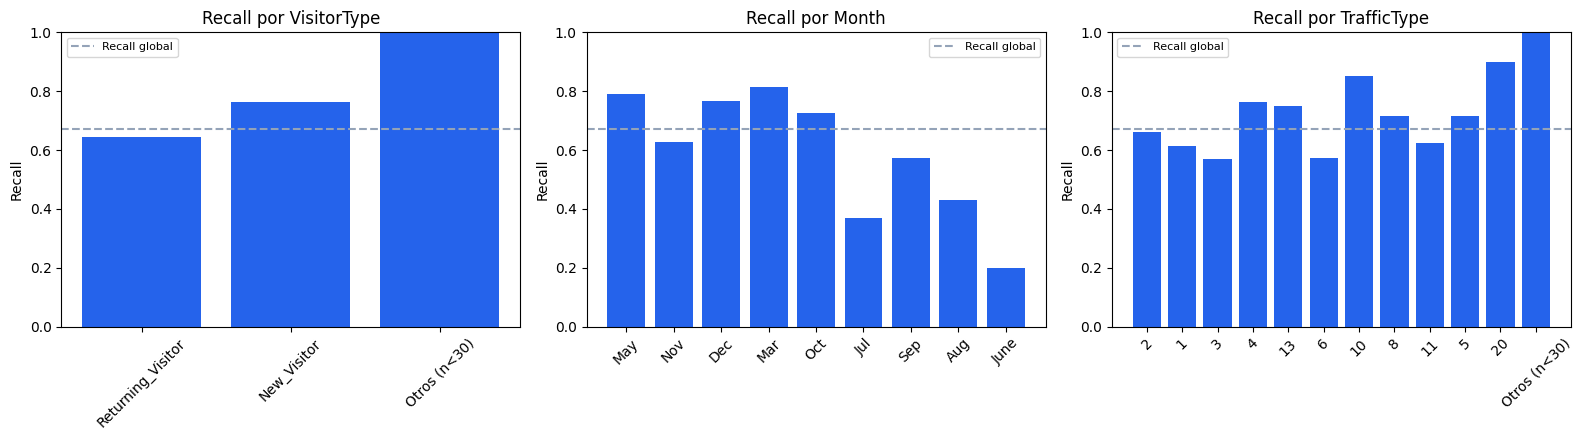

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, (frame, column) in zip(
    axes, [(visitor_metrics, 'VisitorType'), (month_metrics, 'Month'), (traffic_metrics, 'TrafficType')]
):
    plot_frame = frame.dropna(subset=['recall'])
    axis.bar(plot_frame[column].astype(str), plot_frame['recall'], color='#2563eb')
    axis.axhline(overall_metrics['recall'], color='#94a3b8', linestyle='--', label='Recall global')
    axis.set(title=f'Recall por {column}', ylabel='Recall', ylim=(0, 1))
    axis.tick_params(axis='x', rotation=45)
    axis.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'model_recall_by_segment.png', dpi=150)
plt.show()

## 3. Conclusión y recomendación

- El recall global del modelo sobre el conjunto de prueba es de **67,3&nbsp;%**
  (precisión 66,9&nbsp;%, PR-AUC 0,732), pero al desagregar por `VisitorType`
  aparece una diferencia notable: en sesiones de **visitantes nuevos** el
  recall llega a **76,3&nbsp;%** y la precisión a **87,1&nbsp;%**, mientras
  que en **visitantes recurrentes** —el 87&nbsp;% del tráfico de prueba—
  el recall cae a **64,3&nbsp;%** y la precisión a **61,8&nbsp;%**. El
  modelo predice mejor justo en el segmento más pequeño.
- Por mes, **junio** (recall 20&nbsp;%, precisión 14,3&nbsp;%, tasa real de
  compra 8,1&nbsp;%) y **agosto** (recall 42,9&nbsp;%, precisión 37,5&nbsp;%)
  muestran el desempeño más débil, coincidiendo con los meses de menor
  volumen de sesiones y menor tasa de conversión real: hay pocos ejemplos
  positivos de los que aprender. Febrero no pudo evaluarse (0 compras en el
  conjunto de prueba para ese mes).
- Por `TrafficType`, las fuentes más grandes (tipos 1 y 3, ya identificadas
  en la Entrega 1 como de baja conversión) también muestran precisión y
  recall más bajos (56–68&nbsp;%) que fuentes con mayor tasa de conversión
  real.
- **Recomendación:** monitorear el desempeño por segmento cuando se
  actualice el modelo, no solo la métrica agregada — un reporte agregado de
  67&nbsp;% de recall esconde que el modelo es notablemente menos confiable
  justo en el segmento más numeroso (visitantes recurrentes). Vale la pena
  evaluar más adelante un umbral de decisión distinto por tipo de visitante,
  y priorizar la recolección de más datos para los meses con pocas sesiones
  antes de confiar en el modelo para esos periodos.

*Nota: esta evaluación usa el candidato Random Forest del pipeline del
equipo (no el modelo campeón en CatBoost, gestionado por separado vía DVC),
por lo que las cifras exactas pueden diferir del reporte principal; el
objetivo de este análisis es la comparación relativa entre segmentos, no la
métrica agregada final del proyecto.*